## Preprocessing
**Purpose:** Build leakage-aware, model-ready datasets for `U` and `V`, including group split, outlier filtering, V trimming, and collinearity checks.  
**Inputs:** `../data/tbhubbard_database.csv`  
**Outputs:** `../data/processed/clean_data_train_*.csv` and `../data/processed/clean_data_test_*.csv`.


### 1) Load data and create U/V subsets

This block loads the raw table, standardizes column names, and creates two targets:

- `df_u`: on-site interactions (`distance == 0`, target `U`)
- `df_v`: inter-site interactions (`distance != 0`, target `V`)

It also keeps only the columns used downstream and prints baseline row counts.


In [13]:
from pathlib import Path
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.model_selection import GroupShuffleSplit
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt

raw_df = pd.read_csv('../data/tbhubbard_database.csv')
df = raw_df.rename(columns={
    'index_element': 'index_i',
    'element': 'atom_i',
    'ddec_charge_element': 'ddec_charge_i',
    'index_neighbor': 'index_j',
    'element_neighbor': 'atom_j',
    'ddec_charge_neighbor': 'ddec_charge_j',
})
for col in ['atom_i', 'atom_j']:
    df[col] = df[col].astype(str).str.replace(r'^(O|N)\d+$', r'\1', regex=True)

df = df.dropna().copy()

# U subset: on-site interaction rows (distance == 0)
df_u = df[df['distance'] == 0].copy()
df_u = df_u.drop(columns=['distance', 'ddec_charge_j', 'atom_j'])
df_u = df_u.rename(columns={'V': 'U'})

# V subset: inter-site interaction rows (distance != 0)
df_v = df[df['distance'] != 0].copy()
df_v['atom_pair'] = df_v['atom_i'] + '-' + df_v['atom_j']

# Keep only modeling columns used downstream
# This avoids carrying unrelated fields into later design matrices.
df_u = df_u[['qmof_id', 'pld', 'lcd', 'density', 'volume', 'ddec_charge_i', 'atom_i', 'U']].copy()
df_v = df_v[['qmof_id', 'pld', 'lcd', 'density', 'volume', 'ddec_charge_i', 'ddec_charge_j', 'distance', 'atom_i', 'atom_j', 'V', 'atom_pair']].copy()

print('U rows before split:', len(df_u))
print('V rows before split:', len(df_v))


U rows before split: 9617
V rows before split: 454892


### 2) Define preprocessing utility functions

These helper functions keep preprocessing deterministic and leakage-aware:

- **IQR outlier filtering by group** (`remove_outliers_iqr_by_group`)
- **VIF calculation** (`compute_vif`) for multicollinearity diagnostics

All statistical bounds are computed from training data only.


In [2]:

def remove_outliers_iqr_by_group(train_df, test_df, group_col, target_col):
    bounds = (
        train_df.groupby(group_col)[target_col]
        .quantile([0.25, 0.75])
        .unstack()
        .rename(columns={0.25: 'q1', 0.75: 'q3'})
    )
    bounds['iqr'] = bounds['q3'] - bounds['q1']
    bounds['lower'] = bounds['q1'] - 1.5 * bounds['iqr']
    bounds['upper'] = bounds['q3'] + 1.5 * bounds['iqr']

    train_join = train_df.join(bounds[['lower', 'upper']], on=group_col)
    test_join = test_df.join(bounds[['lower', 'upper']], on=group_col)
    test_join['lower'] = test_join['lower'].fillna(-np.inf)
    test_join['upper'] = test_join['upper'].fillna(np.inf)

    train_mask = train_join[target_col].between(train_join['lower'], train_join['upper'])
    test_mask = test_join[target_col].between(test_join['lower'], test_join['upper'])

    return train_join.loc[train_mask, train_df.columns].copy(), test_join.loc[test_mask, test_df.columns].copy()


def compute_vif_table(df_num):
    X = df_num.copy()
    X['intercept'] = 1
    rows = []
    for i, col in enumerate(X.columns[:-1]):
        rows.append({'variable': col, 'vif': variance_inflation_factor(X.values, i)})
    return pd.DataFrame(rows).sort_values('vif', ascending=False)

### 3) Split by material (`qmof_id`)

The split is performed at MOF level so the same material never appears in both train and test sets.
This protects evaluation from material-level leakage.


In [3]:
# MOF-level split: enforce no qmof_id overlap between train/test
random_state = 42
test_size = 0.2

gss = GroupShuffleSplit(test_size=test_size, n_splits=1, random_state=random_state)
train_idx, test_idx = next(gss.split(df, groups=df['qmof_id']))

train_qmofs = set(df.loc[train_idx, 'qmof_id'].unique())
test_qmofs = set(df.loc[test_idx, 'qmof_id'].unique())

print('Train qmof_ids:', len(train_qmofs))
print('Test qmof_ids:', len(test_qmofs))
print('Overlap check:', len(train_qmofs.intersection(test_qmofs)))

# Apply material split to both U and V subsets
df_u_train = df_u[df_u['qmof_id'].isin(train_qmofs)].copy()
df_u_test = df_u[df_u['qmof_id'].isin(test_qmofs)].copy()

df_v_train = df_v[df_v['qmof_id'].isin(train_qmofs)].copy()
df_v_test = df_v[df_v['qmof_id'].isin(test_qmofs)].copy()

print('U train rows:', len(df_u_train), 'U test rows:', len(df_u_test))
print('V train rows:', len(df_v_train), 'V test rows:', len(df_v_test))


Train qmof_ids: 193
Test qmof_ids: 49
Overlap check: 0
U train rows: 7776 U test rows: 1841
V train rows: 373309 V test rows: 81583


### 4) Outlier filtering with training-derived bounds

IQR filtering is applied by chemical grouping using thresholds estimated on training data and then applied to test data.
This preserves a realistic train→test workflow.


In [4]:
# Outlier removal using training-derived IQR bounds (leakage-safe)

df_u_train_clean, df_u_test_clean = remove_outliers_iqr_by_group(
    train_df=df_u_train,
    test_df=df_u_test,
    group_col='atom_i',
    target_col='U',
)

df_v_train_clean, df_v_test_clean = remove_outliers_iqr_by_group(
    train_df=df_v_train,
    test_df=df_v_test,
    group_col='atom_pair',
    target_col='V',
)

print('U cleaned train:', len(df_u_train_clean), 'cleaned test:', len(df_u_test_clean))
print('V cleaned train:', len(df_v_train_clean), 'cleaned test:', len(df_v_test_clean))


U cleaned train: 7083 cleaned test: 1658
V cleaned train: 310815 cleaned test: 67655


### 5) Shape checks after outlier filtering

These printouts provide a quick sanity check on retained sample sizes before trimming and feature preparation.


In [5]:
print('For U train:')
print(f"Original: {len(df_u_train)}, Cleaned: {len(df_u_train_clean)}")
print(f"Removed: {len(df_u_train) - len(df_u_train_clean)} ({100*(len(df_u_train)-len(df_u_train_clean))/len(df_u_train):.1f}%)")

print('For U test :')
print(f"Original: {len(df_u_test)}, Cleaned: {len(df_u_test_clean)}")
print(f"Removed: {len(df_u_test) - len(df_u_test_clean)} ({100*(len(df_u_test)-len(df_u_test_clean))/len(df_u_test):.1f}%)")

print('For V train:')
print(f"Original: {len(df_v_train)}, Cleaned: {len(df_v_train_clean)}")
print(f"Removed: {len(df_v_train) - len(df_v_train_clean)} ({100*(len(df_v_train)-len(df_v_train_clean))/len(df_v_train):.1f}%)")

print('For V test:')
print(f"Original: {len(df_v_test)}, Cleaned: {len(df_v_test_clean)}")
print(f"Removed: {len(df_v_test) - len(df_v_test_clean)} ({100*(len(df_v_test)-len(df_v_test_clean))/len(df_v_test):.1f}%)")

For U train:
Original: 7776, Cleaned: 7083
Removed: 693 (8.9%)
For U test :
Original: 1841, Cleaned: 1658
Removed: 183 (9.9%)
For V train:
Original: 373309, Cleaned: 310815
Removed: 62494 (16.7%)
For V test:
Original: 81583, Cleaned: 67655
Removed: 13928 (17.1%)


### 6) V trimming (`|V| > 0.01 eV`)

This section visualizes `V` before trimming, applies the absolute-value threshold, and shows the post-trim distributions.
Use the printed percentages to document how much of the near-zero tail is removed in each split.


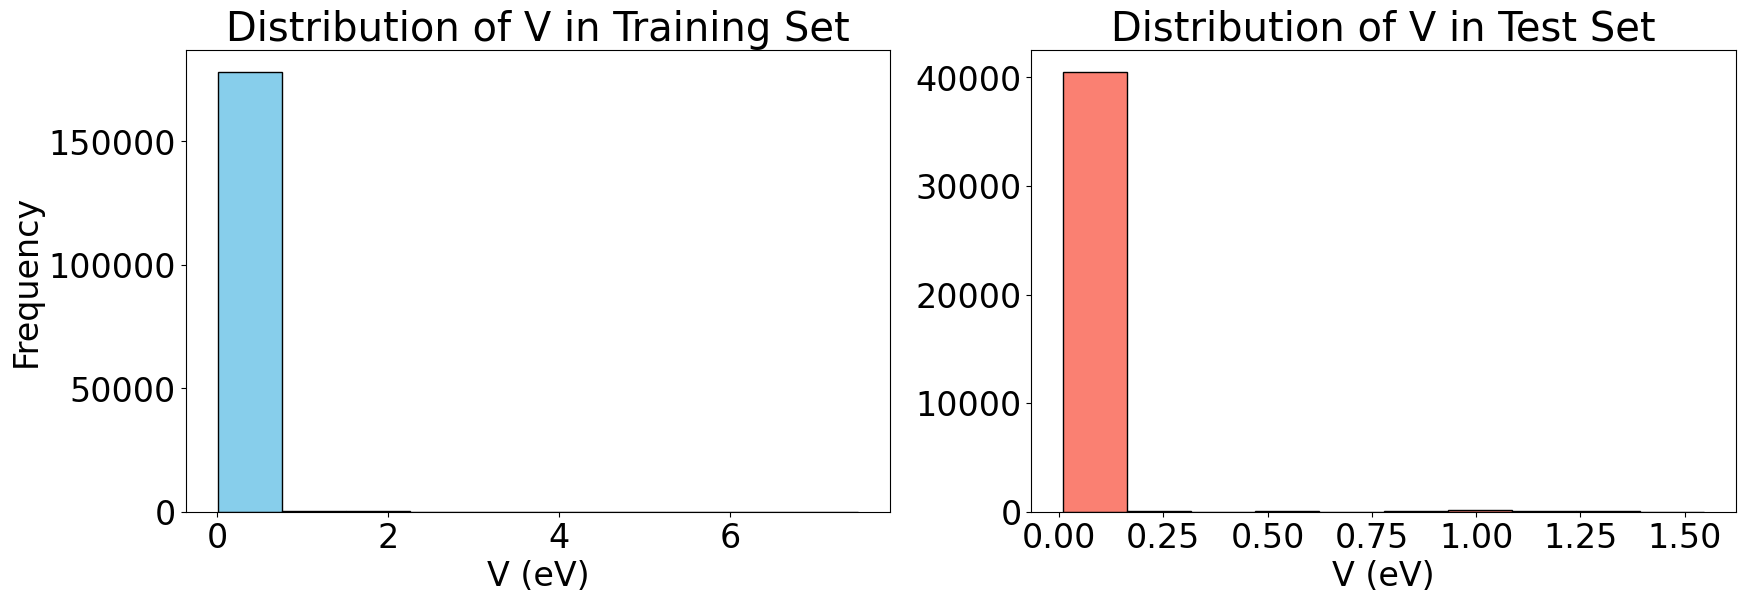

In [25]:
plt.rcParams['font.size'] = 24

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

axes[0].hist(abs(df_v_train_clean['V'].values), color='skyblue', edgecolor='k')
axes[0].set_xlabel('V (eV)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of V in Training Set')

axes[1].hist(abs(df_v_test_clean['V'].values), color='salmon', edgecolor='k')
axes[1].set_xlabel('V (eV)')
# axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of V in Test Set')
plt.show()

In [15]:
threshold = 0.01

df_v_train_clean.drop(columns=['atom_pair'], inplace=True)
df_v_test_clean.drop(columns=['atom_pair'], inplace=True)

mask_train = abs(df_v_train_clean['V'])  > threshold
mask_test = abs(df_v_test_clean['V'])  > threshold

df_v_train_clean_filtered = df_v_train_clean[mask_train].copy()
df_v_test_clean_filtered = df_v_test_clean[mask_test].copy()

print(f"Original train shape: {df_v_train_clean.shape}")
print(f"Filtered train shape: {df_v_train_clean_filtered.shape}")
print(f"Percentage of train samples removed: {100 * (1 - len(df_v_train_clean_filtered) / len(df_v_train_clean)):.2f}%")
print(f"Original test shape: {df_v_test_clean.shape}")
print(f"Filtered test shape: {df_v_test_clean_filtered.shape}")
print(f"Percentage of test samples removed: {100 * (1 - len(df_v_test_clean_filtered) / len(df_v_test_clean)):.2f}%")

Original train shape: (310815, 11)
Filtered train shape: (178924, 11)
Percentage of train samples removed: 42.43%
Original test shape: (67655, 11)
Filtered test shape: (40927, 11)
Percentage of test samples removed: 39.51%


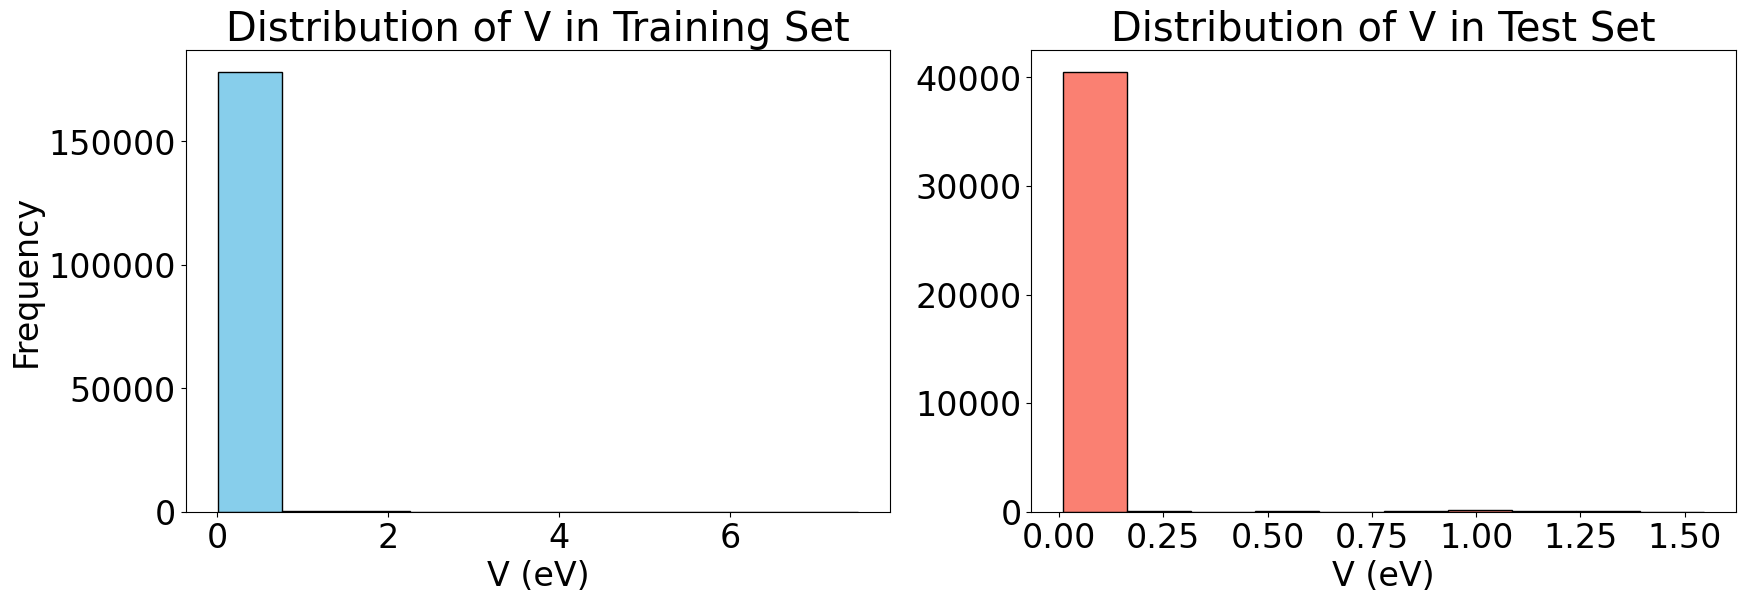

In [26]:
plt.rcParams['font.size'] = 24
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

axes[0].hist(abs(df_v_train_clean_filtered['V'].values), color='skyblue', edgecolor='k')
axes[0].set_xlabel('V (eV)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of V in Training Set')

axes[1].hist(abs(df_v_test_clean_filtered['V'].values), color='salmon', edgecolor='k')
axes[1].set_xlabel('V (eV)')
# axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of V in Test Set')
plt.show()

### 7) Multicollinearity assessment (VIF)

VIF is computed on training structural predictors. The `lcd` drop decision is data-driven (`drop_lcd`) and then applied consistently to train/test final tables.


In [17]:
# Compute VIF on training data and decide whether to drop `lcd`

df_v_train_clean = df_v_train_clean_filtered
df_v_test_clean = df_v_test_clean_filtered

structure_cols = ['pld', 'lcd', 'volume', 'density']
vif_threshold = 5.0

def compute_vif_table(X_df):
    X_const = sm.add_constant(X_df)
    vif = pd.DataFrame({
        'feature': X_const.columns,
        'VIF': [
            variance_inflation_factor(X_const.values, i)
            for i in range(X_const.shape[1])
        ]
    })
    return vif[vif['feature'] != 'const'].copy()

vif_u = compute_vif_table(df_u_train_clean[structure_cols])
vif_v = compute_vif_table(df_v_train_clean[structure_cols])

lcd_vif_u = float(vif_u.set_index('feature').loc['lcd', 'VIF'])
lcd_vif_v = float(vif_v.set_index('feature').loc['lcd', 'VIF'])

drop_lcd = (lcd_vif_u > vif_threshold) or (lcd_vif_v > vif_threshold)

print('U VIF (training only):')
print(vif_u)
print('V VIF (training only):')
print(vif_v)
print(f"lcd VIF (U train)={lcd_vif_u:.4f}, lcd VIF (V train)={lcd_vif_v:.4f}")
print('drop_lcd:', drop_lcd)


U VIF (training only):
   feature       VIF
1      pld  2.308401
2      lcd  6.103442
3   volume  2.748545
4  density  3.523114
V VIF (training only):
   feature       VIF
1      pld  2.582235
2      lcd  6.731465
3   volume  2.755470
4  density  3.742198
lcd VIF (U train)=6.1034, lcd VIF (V train)=6.7315
drop_lcd: True


### 8) Build final modeling tables

Prepare the finalized train/test datasets for `03_modeling.ipynb` after all cleaning, trimming, and optional `lcd` removal.


In [20]:
# Assemble final modeling datasets

if drop_lcd:
    df_u_train_final = df_u_train_clean.drop(columns=['lcd']).copy()
    df_u_test_final = df_u_test_clean.drop(columns=['lcd']).copy()
else:
    df_u_train_final = df_u_train_clean.copy()
    df_u_test_final = df_u_test_clean.copy()

# V final table: `atom_pair` already removed; optionally drop `lcd`
v_drop_cols = (['lcd'] if drop_lcd else [])
df_v_train_final = df_v_train_clean.drop(columns=v_drop_cols).copy()
df_v_test_final = df_v_test_clean.drop(columns=v_drop_cols).copy()


### 9) Save processed artifacts

Persist final train/test CSV files under `../data/processed/` for reproducible downstream runs.


In [21]:
# Save processed train/test artifacts
df_u_train_final.to_csv('../data/processed/clean_data_train_u.csv')
df_v_train_final.to_csv('../data/processed/clean_data_train_v.csv')
df_u_test_final.to_csv('../data/processed/clean_data_test_u.csv')
df_v_test_final.to_csv('../data/processed/clean_data_test_v.csv')


### Preprocessing summary

After running this notebook, verify:

- no `qmof_id` overlap between train/test,
- expected row reductions after IQR + `|V|` trimming,
- `drop_lcd` decision from VIF output,
- successful export of processed CSV files.

If all checks pass, continue to `03_modeling.ipynb`.
